In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import analysis_code.get_data as get_data
import matplotlib.pyplot as plt
import analysis_code.population_activity as pop
import analysis_code.helper_functions as hf
import analysis_code.analysis as analysis
import analysis_code.plots as plots
import analysis_code.statistics_test as st
import analysis_code.simulate_network_downstream as sim_net
import analysis_code.decoding2 as decoding2

from IPython.display import display, HTML
def print_large(text):
    display(HTML(f"<span style='font-size: 20px;'>{text}</span>"))

from pathlib import Path
#OUT = Path("figures"); OUT.mkdir(exist_ok=True)
import matplotlib as mpl
mpl.rcParams.update({
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,   
    "ps.fonttype": 42,    
})

DATA_ROOT = 'DATAPATH'  
datapaths = [
    f'{DATA_ROOT}/170.h5',
    f'{DATA_ROOT}/51004.h5',
    f'{DATA_ROOT}/51007.h5',
    f'{DATA_ROOT}/63.h5',
    f'{DATA_ROOT}/64.h5',
    f'{DATA_ROOT}/65.h5',
]

animal_ids = st.animal_labels(datapaths)

c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
day = '0'
context = 'Context1'
noise_levels = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
results = [sim_net.simulate_shear(datapath, '0', 'Context1', noise_levels = noise_levels, shear_factors= [0.8, 0.9, 1], seed=int(aid))
           for datapath, aid in zip(datapaths, animal_ids)]


c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


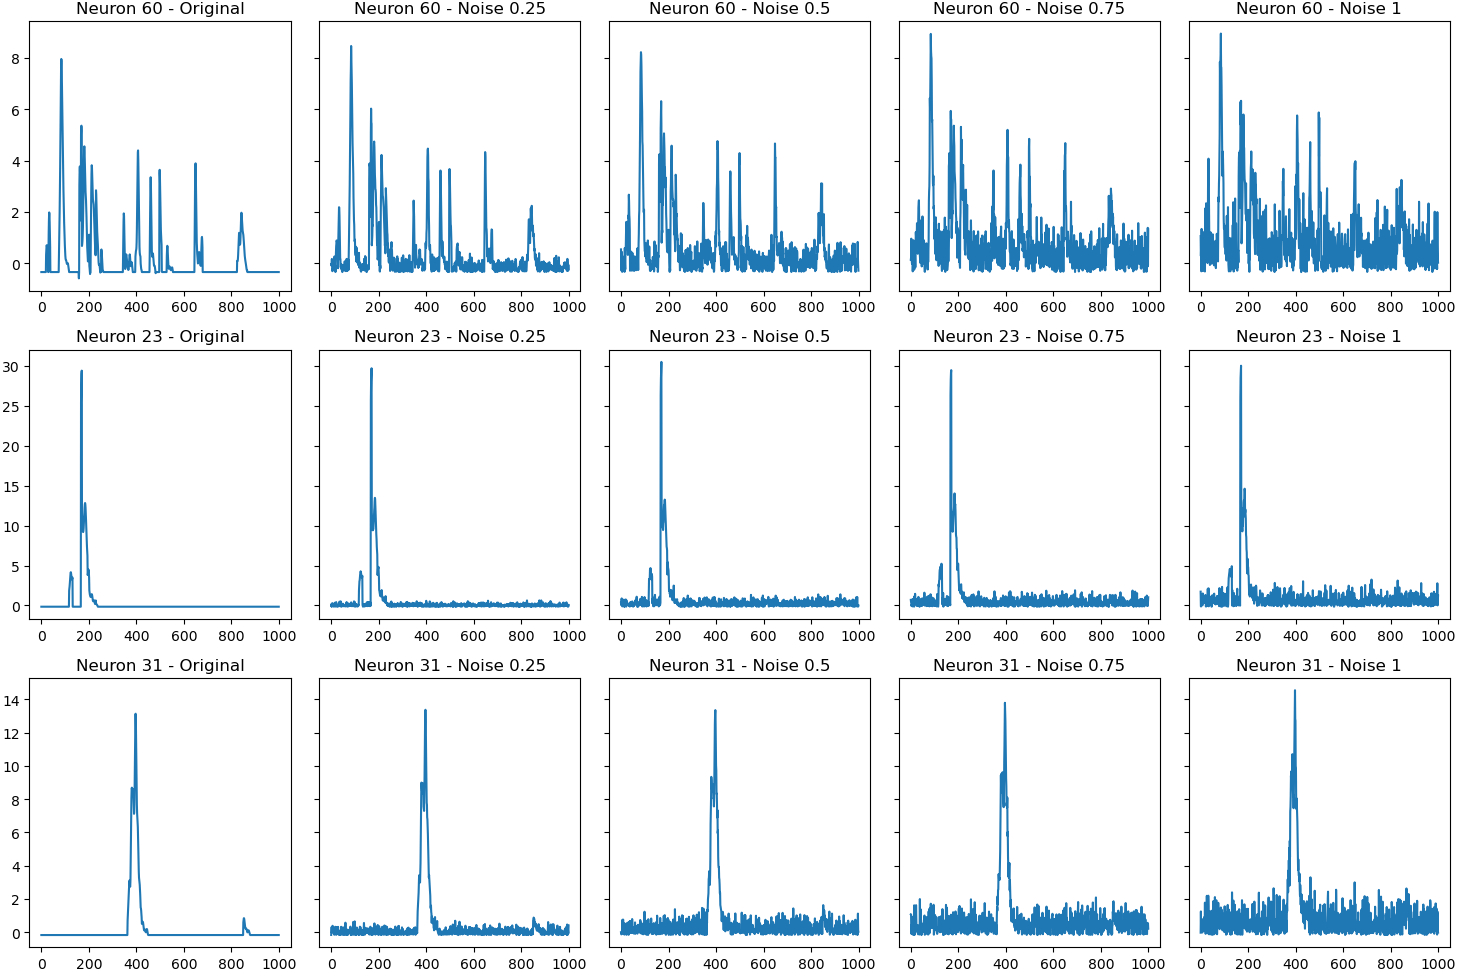

In [3]:
data = analysis.trial_one_session_AK(f'{DATA_ROOT}/63.h5', '0', 'Context1', standardize='stand_m', remove_day_inactive=True)
X = data['calcium']
rng = np.random.default_rng(0)
X_025 = X + np.absolute(rng.normal(0, 0.25, X.shape))
X_05 = X + np.absolute(rng.normal(0, 0.5, X.shape))
X_075 = X + np.absolute(rng.normal(0, 0.75, X.shape))
X_1 = X + np.absolute(rng.normal(0, 1, X.shape))

fig, ax = plt.subplots(3, 5, figsize=(15, 10), sharey='row')
neurons = [60, 23, 31]

for i, neuron in enumerate(neurons):
    ax[i, 0].plot(X[neuron][0:1000])
    ax[i, 0].set_title(f'Neuron {neuron} - Original')
    ax[i, 1].plot(X_025[neuron][0:1000])
    ax[i, 1].set_title(f'Neuron {neuron} - Noise 0.25')
    ax[i, 2].plot(X_05[neuron][0:1000])
    ax[i, 2].set_title(f'Neuron {neuron} - Noise 0.5')
    ax[i, 3].plot(X_075[neuron][0:1000])
    ax[i, 3].set_title(f'Neuron {neuron} - Noise 0.75')
    ax[i, 4].plot(X_1[neuron][0:1000])
    ax[i, 4].set_title(f'Neuron {neuron} - Noise 1')

plt.tight_layout()
plt.show()

In [4]:
mae_values_original = []
mae_values_controlled_0_5 = []
mae_values_controlled_0_75 = []
mae_values_controlled_1 = []
mae_values_rotation = []

for res in results:
    mae_list_original = []
    mae_list_controlled_0_5 = []
    mae_list_controlled_0_75 = []
    mae_list_controlled_1 = []
    mae_list_rotation = []
    
    for key in noise_levels:
        mae_list_original.append(res['original']['final'][key]['mae'])
        mae_list_controlled_0_5.append(res['controlled_0.8']['final'][key]['mae'])
        mae_list_controlled_0_75.append(res['controlled_0.9']['final'][key]['mae'])
        mae_list_controlled_1.append(res['controlled_1']['final'][key]['mae'])
        mae_list_rotation.append(res['rotation']['final'][key]['mae'])
    
    mae_values_original.append(mae_list_original)
    mae_values_controlled_0_5.append(mae_list_controlled_0_5)
    mae_values_controlled_0_75.append(mae_list_controlled_0_75)
    mae_values_controlled_1.append(mae_list_controlled_1)
    mae_values_rotation.append(mae_list_rotation)

mae_array_original = np.array(mae_values_original)
mae_array_controlled_0_5 = np.array(mae_values_controlled_0_5)
mae_array_controlled_0_75 = np.array(mae_values_controlled_0_75)
mae_array_controlled_1 = np.array(mae_values_controlled_1)
mae_array_rotation = np.array(mae_values_rotation)

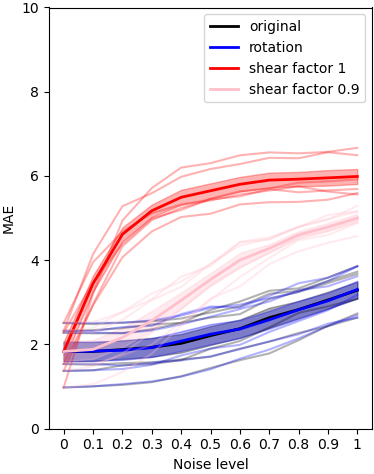

noise level,noise 0,noise 0.1,noise 0.2,noise 0.3,noise 0.4,noise 0.5,noise 0.6,noise 0.7,noise 0.8,noise 0.9,noise 1
animal,,,,,,,,,,,
170,2.3222,2.3410,2.3876,2.4746,2.5121,2.8193,3.0196,3.2739,3.3322,3.5891,3.8634
51004,2.5109,2.4827,2.5170,2.5509,2.6173,2.7573,2.9023,3.2031,3.2743,3.5055,3.7274
51007,1.5360,1.5163,1.5581,1.5762,1.6437,1.7069,1.9016,2.0659,2.2734,2.4342,2.6380
63,2.2788,2.2648,2.2683,2.3596,2.5153,2.6388,2.7202,3.0797,3.2472,3.4577,3.6741
64,0.9796,1.0067,1.0404,1.1057,1.2455,1.4427,1.6275,1.7867,2.1018,2.4458,2.7363
65,1.3722,1.3846,1.5076,1.5339,1.6295,1.8990,2.0823,2.4030,2.7500,2.9049,3.0853


noise level,noise 0,noise 0.1,noise 0.2,noise 0.3,noise 0.4,noise 0.5,noise 0.6,noise 0.7,noise 0.8,noise 0.9,noise 1
animal,,,,,,,,,,,
170,2.3222,2.3185,2.4134,2.4425,2.7215,2.9009,2.8755,3.1524,3.4546,3.5837,3.8518
51004,2.5109,2.5112,2.5166,2.5713,2.6865,2.8691,2.9456,3.0977,3.2491,3.5039,3.8573
51007,1.5360,1.5412,1.4969,1.5671,1.6213,1.7189,1.8871,2.0727,2.2417,2.4947,2.6366
63,2.2788,2.2819,2.2696,2.3328,2.4759,2.6595,2.8403,3.0201,3.2911,3.3811,3.6201
64,0.9796,1.0052,1.0617,1.1225,1.2364,1.4120,1.6624,1.8791,2.1455,2.4385,2.6952
65,1.3722,1.3903,1.4177,1.5165,1.7397,1.9022,1.9908,2.2966,2.5569,2.8155,3.1766


c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\scipy\stats\_morestats.py:1813: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "
c:\Users\oles\Documents\code\Sylte_Kilias_et_al\analysis_code\statistics_test.py:409: RuntimeWarning: invalid value encountered in scalar divide
  effect_size = np.mean(differences) / np.std(differences, ddof=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,32.587575,10,50,3.258758,179.317906,1.461615e-35,0.000007,4.597328e-01,0.122959
1,condition,0.000005,1,5,0.000005,0.002204,9.643708e-01,0.964371,1.278043e-07,1.000000
2,time * condition,0.022831,10,50,0.002283,0.970286,4.804869e-01,0.430114,5.958199e-04,0.284925


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,noise 0,original,rotation,t-test,NaN,nan,nan,,NaN,Cohen's d,1.8333,1.8333,0.0000,0.0000,6,True,1.0000
1,noise 0.1,original,rotation,t-test,-1.1207,0.3134,1.0000,,-0.4575,Cohen's d,1.8327,1.8414,-0.0087,0.0190,6,True,0.6398
2,noise 0.2,original,rotation,t-test,0.8906,0.4139,1.0000,,0.3636,Cohen's d,1.8798,1.8626,0.0172,0.0473,6,True,0.1689
3,noise 0.3,original,rotation,t-test,0.8871,0.4157,1.0000,,0.3621,Cohen's d,1.9335,1.9255,0.0080,0.0221,6,True,0.3402
4,noise 0.4,original,rotation,t-test,-1.3520,0.2343,1.0000,,-0.5520,Cohen's d,2.0272,2.0802,-0.0530,0.0960,6,True,0.3981
5,noise 0.5,original,rotation,t-test,-1.5275,0.1872,1.0000,,-0.6236,Cohen's d,2.2107,2.2438,-0.0331,0.0531,6,True,0.5617
6,noise 0.6,original,rotation,t-test,0.2191,0.8353,1.0000,,0.0894,Cohen's d,2.3756,2.3670,0.0086,0.0964,6,True,0.8846
7,noise 0.7,original,rotation,t-test,1.4346,0.2109,1.0000,,0.5857,Cohen's d,2.6354,2.5864,0.0490,0.0836,6,True,0.1888
8,noise 0.8,original,rotation,t-test,0.1519,0.8852,1.0000,,0.0620,Cohen's d,2.8298,2.8232,0.0067,0.1072,6,True,0.5169
9,noise 0.9,original,rotation,t-test,0.8881,0.4151,1.0000,,0.3626,Cohen's d,3.0562,3.0362,0.0200,0.0551,6,True,0.4290


...

noise level,noise 0,noise 0.1,noise 0.2,noise 0.3,noise 0.4,noise 0.5,noise 0.6,noise 0.7,noise 0.8,noise 0.9,noise 1
animal,,,,,,,,,,,
170,2.3222,2.3410,2.3876,2.4746,2.5121,2.8193,3.0196,3.2739,3.3322,3.5891,3.8634
51004,2.5109,2.4827,2.5170,2.5509,2.6173,2.7573,2.9023,3.2031,3.2743,3.5055,3.7274
51007,1.5360,1.5163,1.5581,1.5762,1.6437,1.7069,1.9016,2.0659,2.2734,2.4342,2.6380
63,2.2788,2.2648,2.2683,2.3596,2.5153,2.6388,2.7202,3.0797,3.2472,3.4577,3.6741
64,0.9796,1.0067,1.0404,1.1057,1.2455,1.4427,1.6275,1.7867,2.1018,2.4458,2.7363
65,1.3722,1.3846,1.5076,1.5339,1.6295,1.8990,2.0823,2.4030,2.7500,2.9049,3.0853


noise level,noise 0,noise 0.1,noise 0.2,noise 0.3,noise 0.4,noise 0.5,noise 0.6,noise 0.7,noise 0.8,noise 0.9,noise 1
animal,,,,,,,,,,,
170,2.3222,4.1470,5.2827,5.5912,5.9804,6.1665,6.2835,6.4309,6.4217,6.5645,6.4929
51004,2.5109,3.9533,4.6754,5.1151,5.3229,5.4206,5.5609,5.6542,5.7550,5.6304,5.5599
51007,1.5360,2.9316,4.0714,4.6831,5.0265,5.1039,5.3251,5.3765,5.3850,5.4375,5.5945
63,2.2788,3.4847,4.3859,4.9889,5.1928,5.4575,5.6373,5.7032,5.8411,5.8730,5.9211
64,0.9796,3.2091,4.9432,5.7125,6.1996,6.3039,6.4916,6.5597,6.5378,6.5722,6.6691
65,1.3722,2.9577,4.3302,4.9526,5.2430,5.4410,5.5173,5.6877,5.6129,5.6568,5.6923


c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\scipy\stats\_morestats.py:1813: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "
c:\Users\oles\Documents\code\Sylte_Kilias_et_al\analysis_code\statistics_test.py:409: RuntimeWarning: invalid value encountered in scalar divide
  effect_size = np.mean(differences) / np.std(differences, ddof=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,88.231169,10,50,8.823117,149.665838,1.148735e-33,0.000019,0.734607,0.116148
1,condition,243.578228,1,5,243.578228,111.259001,1.322900e-04,0.000132,0.884280,1.000000
2,time * condition,32.813314,10,50,3.281331,85.830363,6.305148e-28,0.000022,0.507249,0.138592


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,noise 0,original,shear factor 1,t-test,NaN,nan,nan,,NaN,Cohen's d,1.8333,1.8333,0.0000,0.0000,6,True,1.0000
1,noise 0.1,original,shear factor 1,t-test,-11.4169,9.0262e-05,0.0009,***,-4.6609,Cohen's d,1.8327,3.4472,-1.6146,0.3464,6,True,0.6465
2,noise 0.2,original,shear factor 1,t-test,-10.1933,0.0002,0.0016,**,-4.1614,Cohen's d,1.8798,4.6148,-2.7350,0.6572,6,True,0.2888
3,noise 0.3,original,shear factor 1,t-test,-10.6785,0.0001,0.0012,**,-4.3595,Cohen's d,1.9335,5.1739,-3.2404,0.7433,6,True,0.1687
4,noise 0.4,original,shear factor 1,t-test,-10.2338,0.0002,0.0015,**,-4.1779,Cohen's d,2.0272,5.4942,-3.4670,0.8298,6,True,0.2086
5,noise 0.5,original,shear factor 1,t-test,-10.8193,0.0001,0.0012,**,-4.4170,Cohen's d,2.2107,5.6489,-3.4382,0.7784,6,True,0.2139
6,noise 0.6,original,shear factor 1,t-test,-10.9427,0.0001,0.0011,**,-4.4673,Cohen's d,2.3756,5.8026,-3.4271,0.7671,6,True,0.1455
7,noise 0.7,original,shear factor 1,t-test,-9.7579,0.0002,0.0019,**,-3.9836,Cohen's d,2.6354,5.9021,-3.2667,0.8200,6,True,0.1778
8,noise 0.8,original,shear factor 1,t-test,-10.7653,0.0001,0.0012,**,-4.3949,Cohen's d,2.8298,5.9256,-3.0958,0.7044,6,True,0.0809
9,noise 0.9,original,shear factor 1,t-test,-10.2983,0.0001,0.0015,**,-4.2043,Cohen's d,3.0562,5.9557,-2.8995,0.6897,6,True,0.4415


In [5]:
fig, ax = plt.subplots(figsize=(4, 5))
plots.plot_anova([mae_array_original, mae_array_rotation, mae_array_controlled_1, mae_array_controlled_0_75], noise_levels, colors=['k', 'b', 'r', 'pink'], 
                          labels=['original', 'rotation', 'shear factor 1', 'shear factor 0.9'], 
                          plot_individual=True, ylim=[0, 10], ax=ax, xlabel='Noise level', ylabel='MAE')
plt.show()  

noise_cols = [f'noise {n}' for n in noise_levels]

print_large('\nTWO-WAY REPEATED ANOVA Rotation')
anova=st.repeated_measures_anova_general(
    [mae_array_original,mae_array_rotation],
    row_labels=animal_ids, col_labels=noise_cols, col_name='noise level',
    condition_labels=['original', 'rotation'],
    title='Shear simulation, decoder MAE (d0): original vs rotation')
display(anova[0])
display(anova[1])

print_large('\nTWO-WAY REPEATED ANOVA shear factor 0.9')
anova=st.repeated_measures_anova_general(
    [mae_array_original,mae_array_controlled_0_75],
    row_labels=animal_ids, col_labels=noise_cols, col_name='noise level',
    condition_labels=['original', 'shear factor 0.9'],
    title='Shear simulation, decoder MAE (d0): original vs shear factor 0.9')
display(anova[0])
display(anova[1])

print_large('\nTWO-WAY REPEATED ANOVA shear factor 1')
anova=st.repeated_measures_anova_general(
    [mae_array_original,mae_array_controlled_1],
    row_labels=animal_ids, col_labels=noise_cols, col_name='noise level',
    condition_labels=['original', 'shear factor 1'],
    title='Shear simulation, decoder MAE (d0): original vs shear factor 1')
display(anova[0])
display(anova[1])

In [6]:
drift_values_original = []
drift_values_controlled_0_5 = []
drift_values_controlled_0_75 = []
drift_values_controlled_1 = []
drift_values_rotation = []

for res in results:
    drift_list_original = []
    drift_list_controlled_0_5 = []
    drift_list_controlled_0_75 = []
    drift_list_controlled_1 = []
    drift_list_rotation = []

    for key in noise_levels:
        drift_list_original.append(res['original']['individual'][key]['drift_downstream'])
        drift_list_controlled_0_5.append(res['controlled_0.8']['individual'][key]['drift_downstream'])
        drift_list_controlled_0_75.append(res['controlled_0.9']['individual'][key]['drift_downstream'])
        drift_list_controlled_1.append(res['controlled_1']['individual'][key]['drift_downstream'])
        drift_list_rotation.append(res['rotation']['individual'][key]['drift_downstream'])
    
    drift_values_original.append(drift_list_original)
    drift_values_controlled_0_5.append(drift_list_controlled_0_5)
    drift_values_controlled_0_75.append(drift_list_controlled_0_75)
    drift_values_controlled_1.append(drift_list_controlled_1)
    drift_values_rotation.append(drift_list_rotation)

drift_array_original = np.array(drift_values_original)
drift_array_controlled_0_5 = np.array(drift_values_controlled_0_5)
drift_array_controlled_0_75 = np.array(drift_values_controlled_0_75)
drift_array_controlled_1 = np.array(drift_values_controlled_1)
drift_array_rotation = np.array(drift_values_rotation)

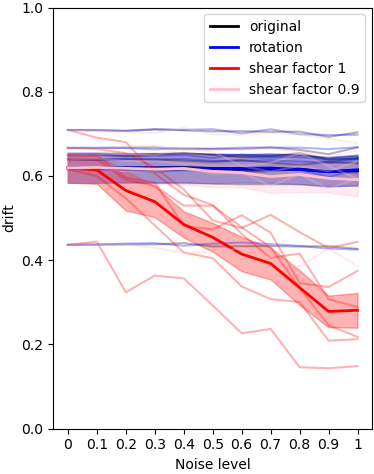

noise level,noise 0,noise 0.1,noise 0.2,noise 0.3,noise 0.4,noise 0.5,noise 0.6,noise 0.7,noise 0.8,noise 0.9,noise 1
animal,,,,,,,,,,,
170,0.4366,0.4368,0.4374,0.4375,0.4407,0.4327,0.4332,0.4337,0.4324,0.4334,0.4269
51004,0.6163,0.6172,0.6147,0.6095,0.6163,0.6184,0.6095,0.6116,0.6165,0.6109,0.6078
51007,0.6492,0.6499,0.6473,0.6501,0.6546,0.6498,0.6449,0.6469,0.6543,0.6384,0.6416
63,0.6667,0.6665,0.6673,0.6678,0.6643,0.6645,0.6641,0.6677,0.6620,0.6517,0.6681
64,0.7093,0.7091,0.7075,0.7110,0.7083,0.7058,0.7065,0.7048,0.7054,0.6927,0.7037
65,0.6395,0.6389,0.6398,0.6391,0.6365,0.6337,0.6376,0.6318,0.6262,0.6331,0.6297


noise level,noise 0,noise 0.1,noise 0.2,noise 0.3,noise 0.4,noise 0.5,noise 0.6,noise 0.7,noise 0.8,noise 0.9,noise 1
animal,,,,,,,,,,,
170,0.4366,0.4377,0.4393,0.4407,0.4344,0.4394,0.4420,0.4384,0.4341,0.4277,0.4254
51004,0.6163,0.6156,0.6157,0.6135,0.6133,0.6139,0.6124,0.6135,0.6147,0.5983,0.6139
51007,0.6492,0.6513,0.6477,0.6481,0.6499,0.6430,0.6505,0.6458,0.6441,0.6409,0.6412
63,0.6667,0.6668,0.6663,0.6632,0.6654,0.6643,0.6674,0.6674,0.6673,0.6638,0.6683
64,0.7093,0.7083,0.7066,0.7104,0.7097,0.7111,0.7010,0.7110,0.6991,0.6974,0.6977
65,0.6395,0.6387,0.6404,0.6389,0.6407,0.6358,0.6363,0.6364,0.6343,0.6323,0.6417


c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\scipy\stats\_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,0.001077,10,50,0.000108,9.357379,1.643269e-08,0.000430,0.001097,0.351445
1,condition,0.000009,1,5,0.000009,0.697929,4.415598e-01,0.441560,0.000009,1.000000
2,time * condition,0.000044,10,50,0.000004,0.389336,9.454455e-01,0.780898,0.000045,0.332292


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,noise 0,original,rotation,wilcoxon,0.0000,0.1088,1.0000,,0.8987,r,0.6196,0.6196,-0.0000,0.0000,6,False,0.0366
1,noise 0.1,original,rotation,t-test,0.0216,0.9836,1.0000,,0.0088,Cohen's d,0.6198,0.6197,0.0000,0.0011,6,True,0.9846
2,noise 0.2,original,rotation,t-test,-0.7232,0.5019,1.0000,,-0.2953,Cohen's d,0.6190,0.6193,-0.0003,0.0011,6,True,0.5494
3,noise 0.3,original,rotation,t-test,0.0248,0.9811,1.0000,,0.0101,Cohen's d,0.6192,0.6191,0.0000,0.0032,6,True,0.7631
4,noise 0.4,original,rotation,t-test,0.7497,0.4872,1.0000,,0.3061,Cohen's d,0.6201,0.6189,0.0012,0.0041,6,True,0.6989
5,noise 0.5,original,rotation,t-test,-0.2117,0.8407,1.0000,,-0.0864,Cohen's d,0.6175,0.6179,-0.0005,0.0053,6,True,0.7493
6,noise 0.6,original,rotation,t-test,-1.1240,0.3120,1.0000,,-0.4589,Cohen's d,0.6159,0.6183,-0.0023,0.0051,6,True,0.9032
7,noise 0.7,original,rotation,t-test,-2.2053,0.0786,0.8642,,-0.9003,Cohen's d,0.6161,0.6188,-0.0027,0.0030,6,True,0.4872
8,noise 0.8,original,rotation,t-test,0.1909,0.8561,1.0000,,0.0779,Cohen's d,0.6161,0.6156,0.0005,0.0069,6,True,0.9029
9,noise 0.9,original,rotation,t-test,-0.0028,0.9979,1.0000,,-0.0011,Cohen's d,0.6101,0.6101,-0.0000,0.0086,6,True,0.9966


...

,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,noise 0,original,shear factor 0.9,t-test,-2.0585,0.0946,1.0000,,-0.8404,Cohen's d,0.6196,0.6196,-0.0000,0.0000,6,True,0.2937
1,noise 0.1,original,shear factor 0.9,t-test,-1.1948,0.2858,1.0000,,-0.4878,Cohen's d,0.6198,0.6204,-0.0006,0.0013,6,True,0.9824
2,noise 0.2,original,shear factor 0.9,t-test,0.5640,0.5971,1.0000,,0.2302,Cohen's d,0.6190,0.6181,0.0009,0.0038,6,True,0.1777
3,noise 0.3,original,shear factor 0.9,t-test,1.4128,0.2168,1.0000,,0.5768,Cohen's d,0.6192,0.6163,0.0029,0.0050,6,True,0.6479
4,noise 0.4,original,shear factor 0.9,t-test,0.4726,0.6564,1.0000,,0.1929,Cohen's d,0.6201,0.6178,0.0023,0.0121,6,True,0.6243
5,noise 0.5,original,shear factor 0.9,t-test,1.9305,0.1114,1.0000,,0.7881,Cohen's d,0.6175,0.6110,0.0065,0.0083,6,True,0.3296
6,noise 0.6,original,shear factor 0.9,t-test,2.5431,0.0517,0.5687,,1.0382,Cohen's d,0.6159,0.6078,0.0081,0.0078,6,True,0.3927
7,noise 0.7,original,shear factor 0.9,t-test,3.2441,0.0228,0.2513,,1.3244,Cohen's d,0.6161,0.5985,0.0176,0.0133,6,True,0.5242
8,noise 0.8,original,shear factor 0.9,wilcoxon,0.0000,0.0312,0.3438,,0.8987,r,0.6161,0.6036,0.0125,0.0180,6,False,0.0066
9,noise 0.9,original,shear factor 0.9,t-test,2.7478,0.0404,0.4446,,1.1218,Cohen's d,0.6101,0.5944,0.0157,0.0140,6,True,0.1487


noise level,noise 0,noise 0.1,noise 0.2,noise 0.3,noise 0.4,noise 0.5,noise 0.6,noise 0.7,noise 0.8,noise 0.9,noise 1
animal,,,,,,,,,,,
170,0.4366,0.4368,0.4374,0.4375,0.4407,0.4327,0.4332,0.4337,0.4324,0.4334,0.4269
51004,0.6163,0.6172,0.6147,0.6095,0.6163,0.6184,0.6095,0.6116,0.6165,0.6109,0.6078
51007,0.6492,0.6499,0.6473,0.6501,0.6546,0.6498,0.6449,0.6469,0.6543,0.6384,0.6416
63,0.6667,0.6665,0.6673,0.6678,0.6643,0.6645,0.6641,0.6677,0.6620,0.6517,0.6681
64,0.7093,0.7091,0.7075,0.7110,0.7083,0.7058,0.7065,0.7048,0.7054,0.6927,0.7037
65,0.6395,0.6389,0.6398,0.6391,0.6365,0.6337,0.6376,0.6318,0.6262,0.6331,0.6297


noise level,noise 0,noise 0.1,noise 0.2,noise 0.3,noise 0.4,noise 0.5,noise 0.6,noise 0.7,noise 0.8,noise 0.9,noise 1
animal,,,,,,,,,,,
170,0.4366,0.4443,0.3239,0.3637,0.3569,0.2928,0.2265,0.2370,0.1460,0.1435,0.1486
51004,0.6163,0.5998,0.5469,0.4828,0.4182,0.4049,0.3377,0.3075,0.3010,0.2092,0.2126
51007,0.6492,0.6479,0.5961,0.5847,0.4812,0.4730,0.5068,0.4654,0.3457,0.3362,0.3747
63,0.6667,0.6641,0.6543,0.6203,0.5681,0.4947,0.4765,0.5076,0.4667,0.4289,0.4435
64,0.7093,0.6910,0.6804,0.6058,0.5555,0.5311,0.4626,0.4052,0.4160,0.3075,0.2893
65,0.6395,0.6389,0.5912,0.5768,0.5298,0.5295,0.4783,0.4308,0.3344,0.2454,0.2181


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,0.483083,10,50,0.048308,64.369881,4.964881e-25,3.037282e-07,0.311450,0.234065
1,condition,0.890640,1,5,0.890640,156.312337,5.807697e-05,5.807697e-05,0.454726,1.000000
2,time * condition,0.441147,10,50,0.044115,59.206977,3.351180e-24,1.959061e-07,0.292317,0.251040


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,noise 0,original,shear factor 1,t-test,0.6847,0.5240,1.0000,,0.2795,Cohen's d,0.6196,0.6196,0.0000,0.0000,6,True,0.9539
1,noise 0.1,original,shear factor 1,t-test,1.3069,0.2481,1.0000,,0.5336,Cohen's d,0.6198,0.6143,0.0054,0.0102,6,True,0.2520
2,noise 0.2,original,shear factor 1,t-test,3.7333,0.0135,0.1488,,1.5241,Cohen's d,0.6190,0.5655,0.0535,0.0351,6,True,0.6813
3,noise 0.3,original,shear factor 1,t-test,6.5946,0.0012,0.0133,*,2.6922,Cohen's d,0.6192,0.5390,0.0802,0.0298,6,True,0.4687
4,noise 0.4,original,shear factor 1,t-test,7.1587,0.0008,0.0091,**,2.9225,Cohen's d,0.6201,0.4850,0.1352,0.0463,6,True,0.5042
5,noise 0.5,original,shear factor 1,t-test,10.7444,0.0001,0.0013,**,4.3864,Cohen's d,0.6175,0.4543,0.1631,0.0372,6,True,0.7386
6,noise 0.6,original,shear factor 1,t-test,9.7511,0.0002,0.0021,**,3.9809,Cohen's d,0.6159,0.4147,0.2012,0.0505,6,True,0.9082
7,noise 0.7,original,shear factor 1,t-test,8.8270,0.0003,0.0034,**,3.6036,Cohen's d,0.6161,0.3923,0.2238,0.0621,6,True,0.0961
8,noise 0.8,original,shear factor 1,wilcoxon,0.0000,0.0312,0.3438,,0.8987,r,0.6161,0.3350,0.2812,0.0436,6,False,0.0147
9,noise 0.9,original,shear factor 1,t-test,11.4009,9.0877e-05,0.0010,***,4.6544,Cohen's d,0.6101,0.2784,0.3316,0.0712,6,True,0.2885


In [7]:
fig, ax = plt.subplots(figsize=(4, 5))
plots.plot_anova([drift_array_original, drift_array_rotation, drift_array_controlled_1, drift_array_controlled_0_75], noise_levels, colors=['k', 'b', 'r', 'pink'], 
                          labels=['original', 'rotation', 'shear factor 1', 'shear factor 0.9'], 
                          plot_individual=True, ylim=[0, 1], ax=ax, xlabel='Noise level', ylabel='drift')
plt.show()  

noise_cols = [f'noise {n}' for n in noise_levels]

print_large('\nTWO-WAY REPEATED ANOVA Rotation')
anova=st.repeated_measures_anova_general(
    [drift_array_original,drift_array_rotation],
    row_labels=animal_ids, col_labels=noise_cols, col_name='noise level',
    condition_labels=['original', 'rotation'],
    title='Downstream drift (d0): original vs rotation')
display(anova[0])
display(anova[1])

print_large('\nTWO-WAY REPEATED ANOVA shear factor 0.9')
anova=st.repeated_measures_anova_general(
    [drift_array_original,drift_array_controlled_0_75],
    row_labels=animal_ids, col_labels=noise_cols, col_name='noise level',
    condition_labels=['original', 'shear factor 0.9'],
    title='Downstream drift (d0): original vs shear factor 0.9')
display(anova[0])
display(anova[1])

print_large('\nTWO-WAY REPEATED ANOVA shear factor 1')
anova=st.repeated_measures_anova_general(
    [drift_array_original,drift_array_controlled_1],
    row_labels=animal_ids, col_labels=noise_cols, col_name='noise level',
    condition_labels=['original', 'shear factor 1'],
    title='Downstream drift (d0): original vs shear factor 1')
display(anova[0])
display(anova[1])

In [8]:
results_list = []
for datapath, aid in zip(datapaths, animal_ids):
    res = sim_net.simulate_random_transform(datapath, day='0', context='Context1',  noise=1, n_transforms=50, seed=int(aid))
    results_list.append(res)

,animal,observation,orthogonality,MAE - original MAE
0,170,transform 1,0.8509,0.3555
1,170,transform 2,0.8335,0.1882
2,170,transform 3,0.2152,0.1303
3,170,transform 4,4.4396,1.0092
4,170,transform 5,2.5240,0.8164
5,170,transform 6,1.4909,0.2644
6,170,transform 7,0.8354,0.2286
7,170,transform 8,3.0935,1.0845
8,170,transform 9,0.4669,0.1349
9,170,transform 10,1.8638,0.1782


observation,transform 1,transform 2,transform 3,transform 4,transform 5,transform 6,transform 7,transform 8,transform 9,transform 10,transform 11,transform 12,transform 13,transform 14,transform 15,transform 16,transform 17,transform 18,transform 19,transform 20,transform 21,transform 22,transform 23,transform 24,transform 25,transform 26,transform 27,transform 28,transform 29,transform 30,transform 31,transform 32,transform 33,transform 34,transform 35,transform 36,transform 37,transform 38,transform 39,transform 40,transform 41,transform 42,transform 43,transform 44,transform 45,transform 46,transform 47,transform 48,transform 49,transform 50
animal,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
170,0.8509,0.8335,0.2152,4.4396,2.5240,1.4909,0.8354,3.0935,0.4669,1.8638,10.7835,1.8313,5.1995,3.4475,1.6602,0.7200,1.7895,0.9743,1.0622,0.2875,0.1605,0.7540,1.3694,0.9640,4.4953,0.2193,4.2772,0.4788,3.9094,0.6827,1.4339,2.2825,0.3695,1.5155,9.2600,8.2842,7.8322,3.0377,0.9245,0.0845,0.2419,0.9600,1.0092,1.1744,2.8004,1.8507,0.6257,1.6374,2.2095,6.3724
51004,1.8677,1.6148,6.1031,1.8942,1.6467,1.5437,0.9710,1.6491,0.4441,2.8887,1.0260,2.1584,0.6431,0.8233,2.9359,0.2871,0.4271,1.2229,2.6339,0.4551,0.5419,4.1174,0.6148,1.7942,1.7622,2.2984,0.6110,0.6196,0.1745,1.6516,1.2677,2.3340,1.6670,3.1421,4.3418,2.4365,3.7186,2.9566,2.8935,1.1870,0.7670,0.2994,5.7166,1.9034,0.1148,2.8801,1.6245,5.1602,5.6667,1.2693
51007,0.5650,3.4352,7.1909,0.2326,1.6898,5.8382,6.6222,1.0995,2.2227,0.0253,3.9883,3.5593,0.6969,0.3770,0.2277,6.0944,4.0985,1.5836,6.9392,3.5127,0.4368,4.4578,6.8779,2.2966,3.0322,0.9830,1.1640,1.3119,0.5029,0.3262,1.4630,2.2727,6.6826,1.2035,1.8267,4.7506,1.0264,1.9509,5.1870,0.6982,5.5167,3.9302,1.9920,0.4508,0.6241,0.2662,1.0719,1.4066,0.5852,1.8849
63,0.9880,2.9485,1.9616,1.9869,6.2259,0.7153,7.6713,1.8977,2.2682,1.1224,1.1660,1.9329,0.7182,2.2784,2.3893,4.9888,4.4804,2.0808,2.0440,0.5381,6.6198,0.2969,2.4598,5.3855,6.2253,1.8768,0.2297,1.2630,0.4351,3.3055,0.6998,5.3334,1.0077,2.2862,1.4604,0.2799,0.6584,1.7317,1.5676,5.1520,1.7795,1.8089,3.4085,2.6797,0.5303,3.2769,2.7068,0.7630,4.3916,5.4313
64,2.1320,1.8330,2.8612,0.5124,3.6408,2.4815,0.9098,3.4361,0.7346,3.8102,2.0489,1.2884,0.1317,1.2686,4.9069,4.3037,0.1216,0.4508,2.1990,1.0750,4.1198,0.4668,0.4456,0.1008,0.9468,0.3084,0.4014,0.5098,0.7396,0.5280,5.0277,0.8958,4.4919,0.1416,2.1445,3.5233,1.1288,0.7001,3.1437,4.1202,0.2594,0.3689,5.7323,1.4359,2.2300,0.8422,0.8984,0.5337,2.4661,2.8084
65,2.2111,5.8635,0.6630,1.2848,1.8115,1.1406,5.2842,0.4678,1.0895,0.8259,0.8607,4.9904,4.5931,1.4066,0.1226,0.6960,1.0360,2.0244,0.5876,2.2213,2.1356,2.7052,0.7754,6.2882,0.6429,0.9104,0.5940,0.7973,1.6003,0.7840,0.0975,0.9316,0.7359,0.6490,1.2354,5.6951,4.8760,6.0747,1.3445,2.2155,1.3509,0.7423,4.2675,0.3218,1.0899,0.6832,2.7152,1.2158,1.0216,0.7761


observation,transform 1,transform 2,transform 3,transform 4,transform 5,transform 6,transform 7,transform 8,transform 9,transform 10,transform 11,transform 12,transform 13,transform 14,transform 15,transform 16,transform 17,transform 18,transform 19,transform 20,transform 21,transform 22,transform 23,transform 24,transform 25,transform 26,transform 27,transform 28,transform 29,transform 30,transform 31,transform 32,transform 33,transform 34,transform 35,transform 36,transform 37,transform 38,transform 39,transform 40,transform 41,transform 42,transform 43,transform 44,transform 45,transform 46,transform 47,transform 48,transform 49,transform 50
animal,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
170,0.3555,0.1882,0.1303,1.0092,0.8164,0.2644,0.2286,1.0845,0.1349,0.1782,0.9384,0.3243,1.6099,1.0720,0.4488,0.1907,0.3938,0.2814,0.2298,0.0745,0.1062,0.3622,0.2973,0.2731,0.8651,-0.0608,1.0741,-0.0308,1.5899,0.2744,0.3127,0.5450,0.0870,0.5529,1.7423,1.2227,1.8068,0.5874,0.2298,0.0674,0.0275,0.3022,0.2094,0.3843,0.7590,0.5562,0.0604,0.3376,0.8880,0.8643
51004,0.7214,0.2853,1.3988,0.7200,0.7053,0.6146,0.1212,0.4270,0.0134,0.9725,0.2538,0.7912,0.0809,-0.0312,1.1688,0.0342,0.0661,0.4465,0.3763,-0.0138,0.0725,1.3330,0.1229,0.3511,0.4129,0.6801,0.0406,0.0554,0.0789,0.4988,0.2541,1.0319,0.3320,1.2622,0.6593,0.3219,1.3209,0.9486,1.0205,0.3491,0.1195,0.0312,1.8362,0.4924,0.1222,0.6593,0.1997,1.0060,1.4549,0.2622
51007,0.1239,1.5149,1.5283,0.0867,0.4561,1.9910,1.2972,0.2948,0.9521,-0.0235,1.5734,1.2505,0.1906,0.0561,0.0558,2.1315,1.5874,0.4378,1.2275,1.0768,-0.0517,1.8934,2.0818,1.0060,1.4124,0.2316,0.2529,0.4873,0.0446,-0.0372,0.3186,0.5001,1.4474,0.2420,0.5376,2.0686,0.1419,0.3287,1.0284,0.0719,2.0481,1.2770,0.7088,0.0818,0.0547,-0.0558,0.2912,0.2423,-0.0377,0.5327
63,0.1999,1.1220,0.7784,0.5299,1.0812,0.0364,1.8016,0.5477,0.7093,0.2549,0.1907,0.5362,0.0040,0.5385,0.8740,1.0829,0.8428,0.3012,0.6794,0.0347,1.4690,-0.0111,1.0226,0.7057,1.6005,0.5004,0.1090,0.2761,0.0163,1.7560,0.0268,1.9378,0.2756,0.6203,0.2568,0.0203,0.0393,0.3696,0.4385,1.2541,0.2660,0.5314,0.7091,0.9853,0.1339,0.6492,1.0479,0.1333,1.5869,1.4531
64,0.9310,0.3649,0.8058,-0.0307,1.1507,1.6220,0.1094,1.4078,-0.0030,0.9079,1.0392,0.2583,-0.2437,0.3318,1.3510,1.6533,0.0009,0.0261,0.4740,0.0723,1.8110,-0.0668,-0.0216,-0.1613,0.0988,-0.1267,-0.0921,-0.0091,-0.0125,-0.1370,1.9648,0.0823,1.3263,-0.1793,0.9793,1.1696,0.1285,-0.0501,0.9693,1.2367,-0.1644,0.0173,1.0994,0.4169,0.7490,-0.0043,0.1811,0.0198,0.7174,1.8645
65,0.6170,1.4407,0.0886,0.4079,0.7608,0.2619,0.9678,0.1254,0.3153,0.2321,0.2652,2.0154,1.4225,0.3800,0.1855,0.1154,0.2457,0.6308,0.1628,0.4672,0.7909,0.7700,0.2644,1.6268,0.0869,0.2378,0.0677,0.2340,0.4466,0.2042,0.0474,0.1387,0.1755,0.0485,0.0287,1.3575,1.1603,1.8933,0.2725,1.1571,0.2966,0.1528,2.1127,0.1246,0.1468,0.2229,1.0699,0.4109,0.2088,0.1780


c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: y_std    
No. Observations: 300     Method:             REML     
No. Groups:       6       Scale:              0.2550   
Min. group size:  50      Log-Likelihood:     -226.4560
Max. group size:  50      Converged:          Yes      
Mean group size:  50.0                                 
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.000    0.039  0.000 1.000 -0.077  0.077
x1_std        0.863    0.029 29.443 0.000  0.806  0.921
Group Var     0.004    0.012                           

Intercept     1.000000e+00
x1_std       1.538318e-190
Group Var     4.810006e-01
dtype: float64


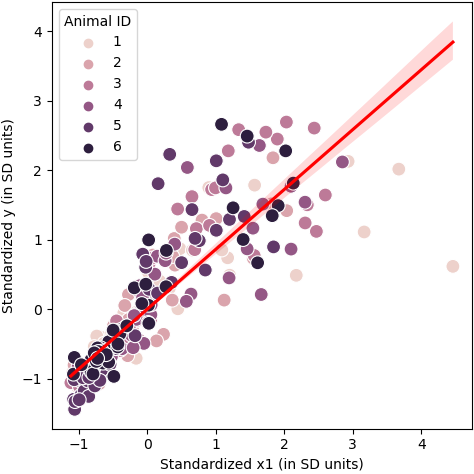

,animal,observation,edge angle,MAE - original MAE
0,170,transform 1,1.2220,0.3555
1,170,transform 2,1.3440,0.1882
2,170,transform 3,0.3518,0.1303
3,170,transform 4,3.3689,1.0092
4,170,transform 5,3.2865,0.8164
5,170,transform 6,1.7557,0.2644
6,170,transform 7,1.2687,0.2286
7,170,transform 8,3.3397,1.0845
8,170,transform 9,0.7881,0.1349
9,170,transform 10,2.4542,0.1782


observation,transform 1,transform 2,transform 3,transform 4,transform 5,transform 6,transform 7,transform 8,transform 9,transform 10,transform 11,transform 12,transform 13,transform 14,transform 15,transform 16,transform 17,transform 18,transform 19,transform 20,transform 21,transform 22,transform 23,transform 24,transform 25,transform 26,transform 27,transform 28,transform 29,transform 30,transform 31,transform 32,transform 33,transform 34,transform 35,transform 36,transform 37,transform 38,transform 39,transform 40,transform 41,transform 42,transform 43,transform 44,transform 45,transform 46,transform 47,transform 48,transform 49,transform 50
animal,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
170,1.2220,1.3440,0.3518,3.3689,3.2865,1.7557,1.2687,3.3397,0.7881,2.4542,5.3943,2.2526,4.1049,3.3719,2.3131,1.1468,2.2899,1.6778,1.6917,0.4947,0.2598,1.0786,1.7775,1.2496,3.5138,0.3559,3.8327,0.7524,3.4948,1.1140,2.0365,2.6057,0.6015,2.0188,4.2086,4.7407,4.0393,2.9233,1.3439,0.1287,0.4118,1.5187,1.7113,1.8056,2.7862,2.3247,1.0199,2.1367,2.3915,4.3239
51004,2.4331,1.5841,3.8270,2.0802,2.0070,1.9743,1.2055,2.2364,0.7040,2.8948,1.3721,2.3564,0.8727,1.1446,2.8080,0.4354,0.6672,1.5695,2.6507,0.6142,0.8355,3.9899,0.9597,2.2678,2.0604,2.3926,0.8254,0.9215,0.2363,2.0132,1.6303,2.5660,1.9387,2.9287,3.5691,3.3283,3.0562,2.7159,2.5939,1.4226,1.0329,0.4446,3.8619,1.9797,0.1766,2.7585,2.0895,3.6268,3.5959,1.7135
51007,0.8790,3.2581,4.3218,0.3491,2.1338,3.9624,4.1479,1.6482,2.3020,0.0386,3.3324,3.3947,1.1146,0.6564,0.3613,3.9697,3.4046,2.0796,3.9192,3.1678,0.6958,3.6799,4.3398,2.5265,2.9772,1.4762,1.7826,1.8588,0.8811,0.5478,2.0077,3.1420,4.4585,1.5468,2.1623,4.1089,1.5122,2.8159,3.8100,1.0453,3.8730,3.3494,2.3369,0.7760,0.9072,0.4395,1.4450,1.7851,0.9067,2.6103
63,1.5597,3.3606,2.4075,2.3897,4.7068,1.2901,5.7470,2.4444,2.8838,1.7120,1.6211,2.5232,1.2122,3.6686,2.7081,3.8654,4.0618,2.7683,2.6045,0.9517,4.2461,0.5258,3.3830,4.6690,4.4713,2.8194,0.4338,1.6821,0.7997,3.5257,1.2399,3.9345,1.4758,2.3749,2.1132,0.4669,1.0889,2.3376,2.1372,3.8301,2.5311,2.2097,3.2956,3.1786,0.9184,3.2631,2.8096,1.2750,3.8043,4.2435
64,2.2681,1.9824,2.6949,0.6636,3.0010,2.4411,1.1596,2.9946,0.9814,3.1768,2.5893,1.4004,0.1784,1.6022,3.2289,3.1410,0.1758,0.6110,2.8328,1.4072,2.7527,0.6781,0.5639,0.1427,1.2650,0.4316,0.6003,0.6126,1.0132,0.6770,3.0890,1.1625,3.6459,0.2049,2.1051,2.8933,1.5630,0.9907,2.6360,3.0479,0.3611,0.5309,3.7093,1.6118,2.8019,1.0176,1.2101,0.7076,2.5550,2.8043
65,2.3376,3.7826,0.9746,1.6227,2.0568,1.5036,3.6328,0.6792,1.4832,1.1582,1.2343,3.8937,3.2518,1.6699,0.1767,1.0351,1.2653,2.3854,0.7986,2.3817,2.4645,2.6600,1.0200,3.7128,0.9931,1.2510,0.9836,1.1071,1.9786,1.1977,0.1388,1.2154,0.9890,0.8891,1.7662,4.8717,3.6011,3.6054,1.7323,2.2527,1.6990,1.1453,3.8875,0.4925,1.5935,0.8719,2.4387,1.5802,1.3646,1.1132


observation,transform 1,transform 2,transform 3,transform 4,transform 5,transform 6,transform 7,transform 8,transform 9,transform 10,transform 11,transform 12,transform 13,transform 14,transform 15,transform 16,transform 17,transform 18,transform 19,transform 20,transform 21,transform 22,transform 23,transform 24,transform 25,transform 26,transform 27,transform 28,transform 29,transform 30,transform 31,transform 32,transform 33,transform 34,transform 35,transform 36,transform 37,transform 38,transform 39,transform 40,transform 41,transform 42,transform 43,transform 44,transform 45,transform 46,transform 47,transform 48,transform 49,transform 50
animal,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
170,0.3555,0.1882,0.1303,1.0092,0.8164,0.2644,0.2286,1.0845,0.1349,0.1782,0.9384,0.3243,1.6099,1.0720,0.4488,0.1907,0.3938,0.2814,0.2298,0.0745,0.1062,0.3622,0.2973,0.2731,0.8651,-0.0608,1.0741,-0.0308,1.5899,0.2744,0.3127,0.5450,0.0870,0.5529,1.7423,1.2227,1.8068,0.5874,0.2298,0.0674,0.0275,0.3022,0.2094,0.3843,0.7590,0.5562,0.0604,0.3376,0.8880,0.8643
51004,0.7214,0.2853,1.3988,0.7200,0.7053,0.6146,0.1212,0.4270,0.0134,0.9725,0.2538,0.7912,0.0809,-0.0312,1.1688,0.0342,0.0661,0.4465,0.3763,-0.0138,0.0725,1.3330,0.1229,0.3511,0.4129,0.6801,0.0406,0.0554,0.0789,0.4988,0.2541,1.0319,0.3320,1.2622,0.6593,0.3219,1.3209,0.9486,1.0205,0.3491,0.1195,0.0312,1.8362,0.4924,0.1222,0.6593,0.1997,1.0060,1.4549,0.2622
51007,0.1239,1.5149,1.5283,0.0867,0.4561,1.9910,1.2972,0.2948,0.9521,-0.0235,1.5734,1.2505,0.1906,0.0561,0.0558,2.1315,1.5874,0.4378,1.2275,1.0768,-0.0517,1.8934,2.0818,1.0060,1.4124,0.2316,0.2529,0.4873,0.0446,-0.0372,0.3186,0.5001,1.4474,0.2420,0.5376,2.0686,0.1419,0.3287,1.0284,0.0719,2.0481,1.2770,0.7088,0.0818,0.0547,-0.0558,0.2912,0.2423,-0.0377,0.5327
63,0.1999,1.1220,0.7784,0.5299,1.0812,0.0364,1.8016,0.5477,0.7093,0.2549,0.1907,0.5362,0.0040,0.5385,0.8740,1.0829,0.8428,0.3012,0.6794,0.0347,1.4690,-0.0111,1.0226,0.7057,1.6005,0.5004,0.1090,0.2761,0.0163,1.7560,0.0268,1.9378,0.2756,0.6203,0.2568,0.0203,0.0393,0.3696,0.4385,1.2541,0.2660,0.5314,0.7091,0.9853,0.1339,0.6492,1.0479,0.1333,1.5869,1.4531
64,0.9310,0.3649,0.8058,-0.0307,1.1507,1.6220,0.1094,1.4078,-0.0030,0.9079,1.0392,0.2583,-0.2437,0.3318,1.3510,1.6533,0.0009,0.0261,0.4740,0.0723,1.8110,-0.0668,-0.0216,-0.1613,0.0988,-0.1267,-0.0921,-0.0091,-0.0125,-0.1370,1.9648,0.0823,1.3263,-0.1793,0.9793,1.1696,0.1285,-0.0501,0.9693,1.2367,-0.1644,0.0173,1.0994,0.4169,0.7490,-0.0043,0.1811,0.0198,0.7174,1.8645
65,0.6170,1.4407,0.0886,0.4079,0.7608,0.2619,0.9678,0.1254,0.3153,0.2321,0.2652,2.0154,1.4225,0.3800,0.1855,0.1154,0.2457,0.6308,0.1628,0.4672,0.7909,0.7700,0.2644,1.6268,0.0869,0.2378,0.0677,0.2340,0.4466,0.2042,0.0474,0.1387,0.1755,0.0485,0.0287,1.3575,1.1603,1.8933,0.2725,1.1571,0.2966,0.1528,2.1127,0.1246,0.1468,0.2229,1.0699,0.4109,0.2088,0.1780


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: y_std    
No. Observations: 300     Method:             REML     
No. Groups:       6       Scale:              0.2339   
Min. group size:  50      Log-Likelihood:     -216.4872
Max. group size:  50      Converged:          Yes      
Mean group size:  50.0                                 
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.000    0.068  0.000 1.000 -0.133  0.133
x1_std        0.888    0.029 30.856 0.000  0.831  0.944
Group Var     0.023    0.037                           

Intercept     1.000000e+00
x1_std       4.629913e-209
Group Var     1.950438e-01
dtype: float64


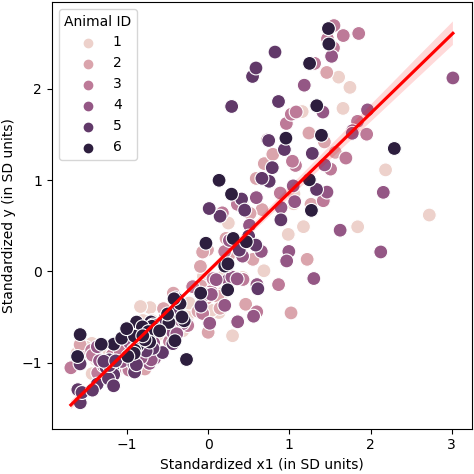

,animal,observation,subspace angle,MAE - original MAE
0,170,transform 1,0.7466,0.3555
1,170,transform 2,0.7588,0.1882
2,170,transform 3,0.2152,0.1303
3,170,transform 4,2.0166,1.0092
4,170,transform 5,1.9848,0.8164
5,170,transform 6,1.0576,0.2644
6,170,transform 7,0.7018,0.2286
7,170,transform 8,1.9492,1.0845
8,170,transform 9,0.4564,0.1349
9,170,transform 10,1.3493,0.1782


observation,transform 1,transform 2,transform 3,transform 4,transform 5,transform 6,transform 7,transform 8,transform 9,transform 10,transform 11,transform 12,transform 13,transform 14,transform 15,transform 16,transform 17,transform 18,transform 19,transform 20,transform 21,transform 22,transform 23,transform 24,transform 25,transform 26,transform 27,transform 28,transform 29,transform 30,transform 31,transform 32,transform 33,transform 34,transform 35,transform 36,transform 37,transform 38,transform 39,transform 40,transform 41,transform 42,transform 43,transform 44,transform 45,transform 46,transform 47,transform 48,transform 49,transform 50
animal,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
170,0.7466,0.7588,0.2152,2.0166,1.9848,1.0576,0.7018,1.9492,0.4564,1.3493,3.3135,1.3939,2.3104,1.9844,1.2524,0.6257,1.3957,0.8434,0.9720,0.2816,0.1464,0.6486,1.1131,0.8336,2.2697,0.2140,2.0545,0.4579,1.9185,0.6509,1.1300,1.3214,0.3421,1.2454,2.7437,2.6709,2.3415,1.7037,0.7128,0.0771,0.2418,0.8946,0.8856,0.9420,1.5738,1.2208,0.5953,1.1048,1.3049,2.6261
51004,1.2740,0.9189,2.7073,1.0848,1.1252,1.0729,0.7021,1.2157,0.3996,1.6003,0.7824,1.3208,0.5023,0.6445,1.5130,0.2536,0.3705,0.9087,1.4097,0.3764,0.4583,2.1363,0.5162,1.2493,1.1665,1.3361,0.5036,0.5512,0.1521,1.0289,0.9094,1.3350,1.0858,1.5861,1.9667,1.7898,1.8011,1.5101,1.6063,0.8866,0.6006,0.2557,2.3695,1.1074,0.1070,1.4544,1.2857,2.1941,1.9355,0.9062
51007,0.5103,1.7509,2.4543,0.2132,1.0820,2.2067,2.6226,0.9504,1.4915,0.0225,1.7764,1.9563,0.6038,0.3844,0.2289,2.3253,2.0332,1.1497,2.3137,2.2198,0.4063,2.0439,2.4371,1.5244,1.6946,0.7613,1.0105,0.9397,0.5018,0.3162,1.0652,2.0329,2.5523,0.9256,1.4669,2.2345,0.8975,1.4543,2.4414,0.6038,2.2724,1.7974,1.2698,0.4494,0.5576,0.2529,0.8404,1.0983,0.5139,1.5102
63,0.8866,2.0378,1.2246,1.3396,3.2985,0.7240,2.8160,1.2189,1.4495,1.0774,0.9663,1.3702,0.6973,2.0508,1.6977,2.4055,2.5937,1.5353,1.3672,0.5543,2.6179,0.3018,1.8632,2.8683,2.5676,1.5216,0.2333,1.0311,0.4611,1.9483,0.6576,2.1086,0.8266,1.3830,1.0836,0.2832,0.6287,1.2881,1.5824,2.1772,1.3840,1.0983,1.8119,1.4722,0.5310,1.7553,1.6288,0.7399,2.2262,2.4783
64,1.2711,1.1471,1.5338,0.4201,1.6232,1.3382,0.6384,1.9500,0.6239,1.9550,1.3934,0.8384,0.1136,0.8711,2.0316,1.9485,0.1048,0.3606,1.5861,0.7413,1.5438,0.3914,0.3458,0.0839,0.6893,0.2552,0.3326,0.3824,0.5866,0.4379,1.8148,0.6601,1.8916,0.1135,1.2427,1.7334,0.7775,0.5531,1.7220,1.7320,0.2058,0.2957,2.4577,0.8926,1.6256,0.6039,0.6576,0.4271,1.3211,1.3598
65,1.3786,2.3828,0.5910,0.8634,1.0857,0.8860,2.2317,0.4145,0.8564,0.6473,0.7278,2.3316,1.8903,0.9506,0.1063,0.5752,0.7276,1.2006,0.4751,1.7968,1.3958,1.4935,0.6146,2.2996,0.5631,0.7161,0.5241,0.6393,1.0421,0.6812,0.0854,0.6914,0.5545,0.5589,0.8775,2.8161,2.2465,2.2131,0.9975,1.2334,0.9205,0.6450,2.3260,0.2859,0.8094,0.5111,1.3174,0.8603,0.7377,0.6549


observation,transform 1,transform 2,transform 3,transform 4,transform 5,transform 6,transform 7,transform 8,transform 9,transform 10,transform 11,transform 12,transform 13,transform 14,transform 15,transform 16,transform 17,transform 18,transform 19,transform 20,transform 21,transform 22,transform 23,transform 24,transform 25,transform 26,transform 27,transform 28,transform 29,transform 30,transform 31,transform 32,transform 33,transform 34,transform 35,transform 36,transform 37,transform 38,transform 39,transform 40,transform 41,transform 42,transform 43,transform 44,transform 45,transform 46,transform 47,transform 48,transform 49,transform 50
animal,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
170,0.3555,0.1882,0.1303,1.0092,0.8164,0.2644,0.2286,1.0845,0.1349,0.1782,0.9384,0.3243,1.6099,1.0720,0.4488,0.1907,0.3938,0.2814,0.2298,0.0745,0.1062,0.3622,0.2973,0.2731,0.8651,-0.0608,1.0741,-0.0308,1.5899,0.2744,0.3127,0.5450,0.0870,0.5529,1.7423,1.2227,1.8068,0.5874,0.2298,0.0674,0.0275,0.3022,0.2094,0.3843,0.7590,0.5562,0.0604,0.3376,0.8880,0.8643
51004,0.7214,0.2853,1.3988,0.7200,0.7053,0.6146,0.1212,0.4270,0.0134,0.9725,0.2538,0.7912,0.0809,-0.0312,1.1688,0.0342,0.0661,0.4465,0.3763,-0.0138,0.0725,1.3330,0.1229,0.3511,0.4129,0.6801,0.0406,0.0554,0.0789,0.4988,0.2541,1.0319,0.3320,1.2622,0.6593,0.3219,1.3209,0.9486,1.0205,0.3491,0.1195,0.0312,1.8362,0.4924,0.1222,0.6593,0.1997,1.0060,1.4549,0.2622
51007,0.1239,1.5149,1.5283,0.0867,0.4561,1.9910,1.2972,0.2948,0.9521,-0.0235,1.5734,1.2505,0.1906,0.0561,0.0558,2.1315,1.5874,0.4378,1.2275,1.0768,-0.0517,1.8934,2.0818,1.0060,1.4124,0.2316,0.2529,0.4873,0.0446,-0.0372,0.3186,0.5001,1.4474,0.2420,0.5376,2.0686,0.1419,0.3287,1.0284,0.0719,2.0481,1.2770,0.7088,0.0818,0.0547,-0.0558,0.2912,0.2423,-0.0377,0.5327
63,0.1999,1.1220,0.7784,0.5299,1.0812,0.0364,1.8016,0.5477,0.7093,0.2549,0.1907,0.5362,0.0040,0.5385,0.8740,1.0829,0.8428,0.3012,0.6794,0.0347,1.4690,-0.0111,1.0226,0.7057,1.6005,0.5004,0.1090,0.2761,0.0163,1.7560,0.0268,1.9378,0.2756,0.6203,0.2568,0.0203,0.0393,0.3696,0.4385,1.2541,0.2660,0.5314,0.7091,0.9853,0.1339,0.6492,1.0479,0.1333,1.5869,1.4531
64,0.9310,0.3649,0.8058,-0.0307,1.1507,1.6220,0.1094,1.4078,-0.0030,0.9079,1.0392,0.2583,-0.2437,0.3318,1.3510,1.6533,0.0009,0.0261,0.4740,0.0723,1.8110,-0.0668,-0.0216,-0.1613,0.0988,-0.1267,-0.0921,-0.0091,-0.0125,-0.1370,1.9648,0.0823,1.3263,-0.1793,0.9793,1.1696,0.1285,-0.0501,0.9693,1.2367,-0.1644,0.0173,1.0994,0.4169,0.7490,-0.0043,0.1811,0.0198,0.7174,1.8645
65,0.6170,1.4407,0.0886,0.4079,0.7608,0.2619,0.9678,0.1254,0.3153,0.2321,0.2652,2.0154,1.4225,0.3800,0.1855,0.1154,0.2457,0.6308,0.1628,0.4672,0.7909,0.7700,0.2644,1.6268,0.0869,0.2378,0.0677,0.2340,0.4466,0.2042,0.0474,0.1387,0.1755,0.0485,0.0287,1.3575,1.1603,1.8933,0.2725,1.1571,0.2966,0.1528,2.1127,0.1246,0.1468,0.2229,1.0699,0.4109,0.2088,0.1780


c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelih

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: y_std    
No. Observations: 300     Method:             REML     
No. Groups:       6       Scale:              0.2618   
Min. group size:  50      Log-Likelihood:     -232.6778
Max. group size:  50      Converged:          No       
Mean group size:  50.0                                 
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.000    0.063  0.000 1.000 -0.124  0.124
x1_std        0.869    0.030 28.626 0.000  0.809  0.928
Group Var     0.019    0.032                           

Intercept     1.000000e+00
x1_std       3.191903e-180
Group Var     2.546878e-01
dtype: float64


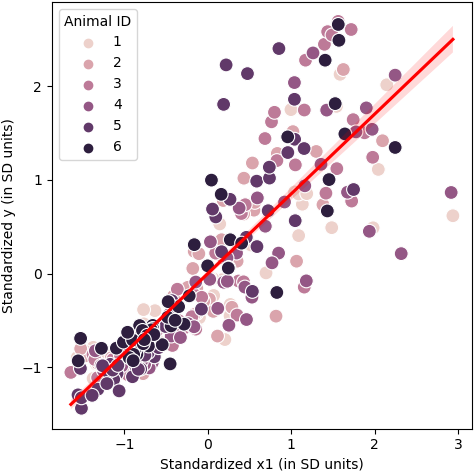

,animal,observation,persistent homology,MAE - original MAE
0,170,transform 1,1.8019,0.3555
1,170,transform 2,1.5087,0.1882
2,170,transform 3,0.0351,0.1303
3,170,transform 4,19.6163,1.0092
4,170,transform 5,13.1241,0.8164
5,170,transform 6,3.0394,0.2644
6,170,transform 7,1.3266,0.2286
7,170,transform 8,13.1862,1.0845
8,170,transform 9,0.2800,0.1349
9,170,transform 10,5.0974,0.1782


observation,transform 1,transform 2,transform 3,transform 4,transform 5,transform 6,transform 7,transform 8,transform 9,transform 10,transform 11,transform 12,transform 13,transform 14,transform 15,transform 16,transform 17,transform 18,transform 19,transform 20,transform 21,transform 22,transform 23,transform 24,transform 25,transform 26,transform 27,transform 28,transform 29,transform 30,transform 31,transform 32,transform 33,transform 34,transform 35,transform 36,transform 37,transform 38,transform 39,transform 40,transform 41,transform 42,transform 43,transform 44,transform 45,transform 46,transform 47,transform 48,transform 49,transform 50
animal,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
170,1.8019,1.5087,0.0351,19.6163,13.1241,3.0394,1.3266,13.1862,0.2800,5.0974,44.7439,5.8868,29.9183,18.0619,5.4275,1.0973,5.9627,2.1748,2.7557,0.0533,0.0189,1.1644,4.0814,1.9029,20.0383,0.0398,15.4784,0.3431,23.3269,1.0886,4.9356,9.1684,0.1284,5.4725,62.7137,31.0767,42.9304,9.9358,1.9212,0.0027,0.0343,2.5150,2.8129,2.9686,13.6192,4.3616,0.7182,4.5181,9.7583,21.9051
51004,9.9506,4.4645,34.9129,9.3882,6.6892,6.9779,2.4546,7.1165,0.3196,16.8804,2.8924,11.5986,0.8401,1.5209,17.3793,0.0830,0.2741,4.1537,10.4285,0.3694,0.6072,24.7674,0.9735,6.5700,7.4811,10.6974,0.8396,1.0139,0.0224,7.6958,4.5237,12.8437,7.0244,17.5426,19.3228,11.2375,22.1869,16.4012,14.9650,4.2730,1.5839,0.0930,41.8671,9.1551,0.0081,15.4872,4.8691,22.8364,37.9676,4.3932
51007,0.7551,16.9515,40.2408,0.0360,5.9669,29.6816,30.7951,4.0792,11.2186,0.0005,20.4830,19.9783,1.2937,0.2039,0.0522,39.8112,29.0737,6.7615,42.5362,21.7498,0.4488,23.0410,41.6953,12.9653,17.3388,3.0823,4.2063,4.1926,0.6031,0.1128,4.7309,8.2565,34.8498,4.0374,7.5885,29.1220,3.1872,8.2297,33.3744,1.3231,35.2970,28.9839,11.0543,0.3894,1.0494,0.0818,3.7014,4.1218,1.0558,9.1889
63,2.1386,13.3077,7.2126,7.2388,15.6833,1.4871,27.5177,7.4686,9.5187,2.9124,2.8434,7.4915,1.2140,8.0335,10.8339,23.0857,17.4956,8.0958,9.1399,0.5486,30.7998,0.1119,11.2270,15.0801,20.0547,7.3150,0.0618,2.8833,0.3659,16.9953,1.1554,27.6529,2.6030,9.5117,3.9367,0.0767,0.9955,5.0384,5.4325,22.5579,5.9124,6.7235,11.5868,11.5766,0.3832,12.9343,13.2614,1.5156,22.0914,24.2265
64,13.1492,9.9800,17.4853,0.6607,26.5157,14.3121,2.9400,23.3006,1.9427,20.8827,13.3350,5.2545,0.0204,6.3532,37.2786,37.9699,0.0127,0.4684,11.5416,4.3247,33.5898,0.4611,0.3567,0.0076,3.3236,0.1305,0.3164,0.6258,1.5743,0.7591,48.3623,2.9553,22.1167,0.0146,14.3295,26.9896,4.0908,1.7504,22.1250,27.8261,0.0462,0.2407,32.7793,7.3121,11.6878,2.5103,2.9410,0.6785,14.8351,21.5439
65,8.2748,37.1513,1.0307,4.2051,8.5224,3.6470,32.9524,0.5722,3.7024,1.9258,2.1155,34.2147,28.0375,5.6525,0.0109,1.1885,2.7309,10.2132,0.6011,7.4171,10.7677,15.2693,1.3903,42.4355,1.1300,2.2790,0.8685,1.5545,6.5782,1.6131,0.0055,2.1469,1.2292,1.0736,3.7034,30.5717,19.6782,38.8405,5.3538,13.3525,5.4220,1.7741,25.3651,0.1138,2.8856,1.2202,14.6139,4.7707,2.6680,1.5994


observation,transform 1,transform 2,transform 3,transform 4,transform 5,transform 6,transform 7,transform 8,transform 9,transform 10,transform 11,transform 12,transform 13,transform 14,transform 15,transform 16,transform 17,transform 18,transform 19,transform 20,transform 21,transform 22,transform 23,transform 24,transform 25,transform 26,transform 27,transform 28,transform 29,transform 30,transform 31,transform 32,transform 33,transform 34,transform 35,transform 36,transform 37,transform 38,transform 39,transform 40,transform 41,transform 42,transform 43,transform 44,transform 45,transform 46,transform 47,transform 48,transform 49,transform 50
animal,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
170,0.3555,0.1882,0.1303,1.0092,0.8164,0.2644,0.2286,1.0845,0.1349,0.1782,0.9384,0.3243,1.6099,1.0720,0.4488,0.1907,0.3938,0.2814,0.2298,0.0745,0.1062,0.3622,0.2973,0.2731,0.8651,-0.0608,1.0741,-0.0308,1.5899,0.2744,0.3127,0.5450,0.0870,0.5529,1.7423,1.2227,1.8068,0.5874,0.2298,0.0674,0.0275,0.3022,0.2094,0.3843,0.7590,0.5562,0.0604,0.3376,0.8880,0.8643
51004,0.7214,0.2853,1.3988,0.7200,0.7053,0.6146,0.1212,0.4270,0.0134,0.9725,0.2538,0.7912,0.0809,-0.0312,1.1688,0.0342,0.0661,0.4465,0.3763,-0.0138,0.0725,1.3330,0.1229,0.3511,0.4129,0.6801,0.0406,0.0554,0.0789,0.4988,0.2541,1.0319,0.3320,1.2622,0.6593,0.3219,1.3209,0.9486,1.0205,0.3491,0.1195,0.0312,1.8362,0.4924,0.1222,0.6593,0.1997,1.0060,1.4549,0.2622
51007,0.1239,1.5149,1.5283,0.0867,0.4561,1.9910,1.2972,0.2948,0.9521,-0.0235,1.5734,1.2505,0.1906,0.0561,0.0558,2.1315,1.5874,0.4378,1.2275,1.0768,-0.0517,1.8934,2.0818,1.0060,1.4124,0.2316,0.2529,0.4873,0.0446,-0.0372,0.3186,0.5001,1.4474,0.2420,0.5376,2.0686,0.1419,0.3287,1.0284,0.0719,2.0481,1.2770,0.7088,0.0818,0.0547,-0.0558,0.2912,0.2423,-0.0377,0.5327
63,0.1999,1.1220,0.7784,0.5299,1.0812,0.0364,1.8016,0.5477,0.7093,0.2549,0.1907,0.5362,0.0040,0.5385,0.8740,1.0829,0.8428,0.3012,0.6794,0.0347,1.4690,-0.0111,1.0226,0.7057,1.6005,0.5004,0.1090,0.2761,0.0163,1.7560,0.0268,1.9378,0.2756,0.6203,0.2568,0.0203,0.0393,0.3696,0.4385,1.2541,0.2660,0.5314,0.7091,0.9853,0.1339,0.6492,1.0479,0.1333,1.5869,1.4531
64,0.9310,0.3649,0.8058,-0.0307,1.1507,1.6220,0.1094,1.4078,-0.0030,0.9079,1.0392,0.2583,-0.2437,0.3318,1.3510,1.6533,0.0009,0.0261,0.4740,0.0723,1.8110,-0.0668,-0.0216,-0.1613,0.0988,-0.1267,-0.0921,-0.0091,-0.0125,-0.1370,1.9648,0.0823,1.3263,-0.1793,0.9793,1.1696,0.1285,-0.0501,0.9693,1.2367,-0.1644,0.0173,1.0994,0.4169,0.7490,-0.0043,0.1811,0.0198,0.7174,1.8645
65,0.6170,1.4407,0.0886,0.4079,0.7608,0.2619,0.9678,0.1254,0.3153,0.2321,0.2652,2.0154,1.4225,0.3800,0.1855,0.1154,0.2457,0.6308,0.1628,0.4672,0.7909,0.7700,0.2644,1.6268,0.0869,0.2378,0.0677,0.2340,0.4466,0.2042,0.0474,0.1387,0.1755,0.0485,0.0287,1.3575,1.1603,1.8933,0.2725,1.1571,0.2966,0.1528,2.1127,0.1246,0.1468,0.2229,1.0699,0.4109,0.2088,0.1780


c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: y_std    
No. Observations: 300     Method:             REML     
No. Groups:       6       Scale:              0.1795   
Min. group size:  50      Log-Likelihood:     -175.7318
Max. group size:  50      Converged:          Yes      
Mean group size:  50.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    -0.000    0.046 -0.000 1.000 -0.089  0.089
x1_std        0.903    0.025 36.730 0.000  0.855  0.951
Group Var     0.009    0.019                           

Intercept     1.000000e+00
x1_std       2.450601e-295
Group Var     2.639221e-01
dtype: float64


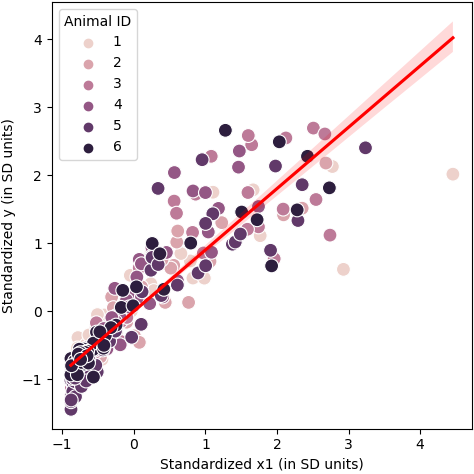

,animal,observation,drift,MAE - original MAE
0,170,transform 1,0.0169,0.3555
1,170,transform 2,0.0191,0.1882
2,170,transform 3,0.0195,0.1303
3,170,transform 4,0.0036,1.0092
4,170,transform 5,-0.0014,0.8164
5,170,transform 6,-0.0027,0.2644
6,170,transform 7,-0.0159,0.2286
7,170,transform 8,-0.0125,1.0845
8,170,transform 9,-0.0071,0.1349
9,170,transform 10,0.0071,0.1782


observation,transform 1,transform 2,transform 3,transform 4,transform 5,transform 6,transform 7,transform 8,transform 9,transform 10,transform 11,transform 12,transform 13,transform 14,transform 15,transform 16,transform 17,transform 18,transform 19,transform 20,transform 21,transform 22,transform 23,transform 24,transform 25,transform 26,transform 27,transform 28,transform 29,transform 30,transform 31,transform 32,transform 33,transform 34,transform 35,transform 36,transform 37,transform 38,transform 39,transform 40,transform 41,transform 42,transform 43,transform 44,transform 45,transform 46,transform 47,transform 48,transform 49,transform 50
animal,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
170,0.0169,0.0191,0.0195,0.0036,-0.0014,-0.0027,-0.0159,-0.0125,-0.0071,0.0071,0.0071,-0.0186,0.0067,0.0067,0.0065,-0.0276,-0.0035,-0.0008,-0.0365,0.0063,0.0253,-0.0065,-0.0052,-0.0368,0.0037,-0.0181,-0.0003,0.0144,0.0179,-0.0315,-0.0115,0.0015,0.0174,0.0040,-0.0023,-0.0002,-0.0091,0.0146,0.0105,0.0114,0.0076,0.0037,0.0053,0.0034,0.0089,0.0026,0.0026,-0.0206,-0.0083,-0.0083
51004,-0.0233,-0.0153,0.0105,0.0005,-0.0065,-0.0067,0.0040,-0.0026,-0.0068,0.0208,-0.0010,0.0055,-0.0023,0.0084,0.0076,-0.0027,-0.0116,-0.0112,-0.0169,-0.0086,0.0045,0.0175,0.0119,0.0064,0.0093,-0.0135,0.0047,-0.0055,0.0025,-0.0048,0.0067,-0.0002,0.0120,-0.0103,0.0148,-0.0039,0.0076,0.0031,0.0250,0.0265,-0.0076,-0.0082,-0.0149,-0.0032,0.0114,0.0030,-0.0161,0.0022,0.0087,-0.0160
51007,0.0085,0.0025,-0.0025,0.0085,0.0072,0.0093,0.0060,-0.0063,-0.0117,-0.0201,0.0071,-0.0167,-0.0085,0.0168,0.0211,-0.0148,0.0185,-0.0012,-0.0057,0.0023,-0.0000,-0.0026,0.0274,-0.0097,0.0006,-0.0069,-0.0151,-0.0041,-0.0049,0.0005,0.0022,0.0073,-0.0033,0.0085,-0.0117,0.0035,-0.0283,0.0039,-0.0189,-0.0047,0.0030,-0.0079,-0.0143,0.0060,0.0011,0.0068,0.0044,0.0044,0.0159,0.0035
63,0.0032,0.0235,0.0066,-0.0073,-0.0247,-0.0022,-0.0030,0.0019,0.0070,0.0061,-0.0008,-0.0035,0.0137,-0.0191,-0.0158,0.0192,-0.0024,0.0022,0.0130,-0.0073,0.0335,-0.0012,0.0168,-0.0008,0.0039,-0.0014,0.0093,-0.0138,0.0054,0.0061,-0.0029,0.0053,-0.0133,0.0010,0.0108,-0.0019,-0.0080,0.0034,-0.0012,-0.0029,-0.0179,0.0114,0.0046,0.0171,0.0054,0.0167,-0.0302,0.0241,0.0029,-0.0310
64,-0.0002,-0.0134,-0.0044,-0.0028,0.0091,0.0027,0.0141,-0.0014,0.0065,-0.0120,0.0216,0.0054,0.0210,-0.0070,-0.0021,0.0156,0.0108,0.0112,-0.0229,0.0033,0.0082,0.0017,-0.0017,0.0054,-0.0029,0.0015,-0.0077,-0.0083,-0.0069,-0.0101,0.0066,-0.0163,-0.0148,-0.0200,-0.0049,0.0188,-0.0010,-0.0109,-0.0054,0.0107,-0.0066,-0.0154,-0.0345,0.0006,-0.0028,-0.0008,-0.0044,-0.0006,0.0031,-0.0082
65,-0.0053,-0.0050,0.0082,0.0023,-0.0074,-0.0044,0.0067,-0.0041,-0.0124,0.0113,-0.0202,0.0077,-0.0098,0.0097,0.0119,-0.0139,0.0016,0.0202,-0.0090,-0.0075,0.0061,0.0072,-0.0123,-0.0022,0.0121,-0.0021,-0.0198,0.0117,-0.0001,-0.0040,0.0057,-0.0156,-0.0051,0.0038,-0.0193,-0.0119,-0.0158,-0.0068,-0.0119,0.0231,0.0133,0.0133,-0.0156,-0.0043,0.0211,-0.0052,-0.0047,0.0134,0.0037,0.0017


observation,transform 1,transform 2,transform 3,transform 4,transform 5,transform 6,transform 7,transform 8,transform 9,transform 10,transform 11,transform 12,transform 13,transform 14,transform 15,transform 16,transform 17,transform 18,transform 19,transform 20,transform 21,transform 22,transform 23,transform 24,transform 25,transform 26,transform 27,transform 28,transform 29,transform 30,transform 31,transform 32,transform 33,transform 34,transform 35,transform 36,transform 37,transform 38,transform 39,transform 40,transform 41,transform 42,transform 43,transform 44,transform 45,transform 46,transform 47,transform 48,transform 49,transform 50
animal,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
170,0.3555,0.1882,0.1303,1.0092,0.8164,0.2644,0.2286,1.0845,0.1349,0.1782,0.9384,0.3243,1.6099,1.0720,0.4488,0.1907,0.3938,0.2814,0.2298,0.0745,0.1062,0.3622,0.2973,0.2731,0.8651,-0.0608,1.0741,-0.0308,1.5899,0.2744,0.3127,0.5450,0.0870,0.5529,1.7423,1.2227,1.8068,0.5874,0.2298,0.0674,0.0275,0.3022,0.2094,0.3843,0.7590,0.5562,0.0604,0.3376,0.8880,0.8643
51004,0.7214,0.2853,1.3988,0.7200,0.7053,0.6146,0.1212,0.4270,0.0134,0.9725,0.2538,0.7912,0.0809,-0.0312,1.1688,0.0342,0.0661,0.4465,0.3763,-0.0138,0.0725,1.3330,0.1229,0.3511,0.4129,0.6801,0.0406,0.0554,0.0789,0.4988,0.2541,1.0319,0.3320,1.2622,0.6593,0.3219,1.3209,0.9486,1.0205,0.3491,0.1195,0.0312,1.8362,0.4924,0.1222,0.6593,0.1997,1.0060,1.4549,0.2622
51007,0.1239,1.5149,1.5283,0.0867,0.4561,1.9910,1.2972,0.2948,0.9521,-0.0235,1.5734,1.2505,0.1906,0.0561,0.0558,2.1315,1.5874,0.4378,1.2275,1.0768,-0.0517,1.8934,2.0818,1.0060,1.4124,0.2316,0.2529,0.4873,0.0446,-0.0372,0.3186,0.5001,1.4474,0.2420,0.5376,2.0686,0.1419,0.3287,1.0284,0.0719,2.0481,1.2770,0.7088,0.0818,0.0547,-0.0558,0.2912,0.2423,-0.0377,0.5327
63,0.1999,1.1220,0.7784,0.5299,1.0812,0.0364,1.8016,0.5477,0.7093,0.2549,0.1907,0.5362,0.0040,0.5385,0.8740,1.0829,0.8428,0.3012,0.6794,0.0347,1.4690,-0.0111,1.0226,0.7057,1.6005,0.5004,0.1090,0.2761,0.0163,1.7560,0.0268,1.9378,0.2756,0.6203,0.2568,0.0203,0.0393,0.3696,0.4385,1.2541,0.2660,0.5314,0.7091,0.9853,0.1339,0.6492,1.0479,0.1333,1.5869,1.4531
64,0.9310,0.3649,0.8058,-0.0307,1.1507,1.6220,0.1094,1.4078,-0.0030,0.9079,1.0392,0.2583,-0.2437,0.3318,1.3510,1.6533,0.0009,0.0261,0.4740,0.0723,1.8110,-0.0668,-0.0216,-0.1613,0.0988,-0.1267,-0.0921,-0.0091,-0.0125,-0.1370,1.9648,0.0823,1.3263,-0.1793,0.9793,1.1696,0.1285,-0.0501,0.9693,1.2367,-0.1644,0.0173,1.0994,0.4169,0.7490,-0.0043,0.1811,0.0198,0.7174,1.8645
65,0.6170,1.4407,0.0886,0.4079,0.7608,0.2619,0.9678,0.1254,0.3153,0.2321,0.2652,2.0154,1.4225,0.3800,0.1855,0.1154,0.2457,0.6308,0.1628,0.4672,0.7909,0.7700,0.2644,1.6268,0.0869,0.2378,0.0677,0.2340,0.4466,0.2042,0.0474,0.1387,0.1755,0.0485,0.0287,1.3575,1.1603,1.8933,0.2725,1.1571,0.2966,0.1528,2.1127,0.1246,0.1468,0.2229,1.0699,0.4109,0.2088,0.1780


c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: y_std    
No. Observations: 300     Method:             REML     
No. Groups:       6       Scale:              0.9999   
Min. group size:  50      Log-Likelihood:     -428.9760
Max. group size:  50      Converged:          Yes      
Mean group size:  50.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    -0.000    0.063 -0.000 1.000 -0.124  0.124
x1_std        0.059    0.058  1.018 0.309 -0.054  0.172
Group Var     0.004    0.015                           

Intercept    1.000000
x1_std       0.308808
Group Var    0.801120
dtype: float64


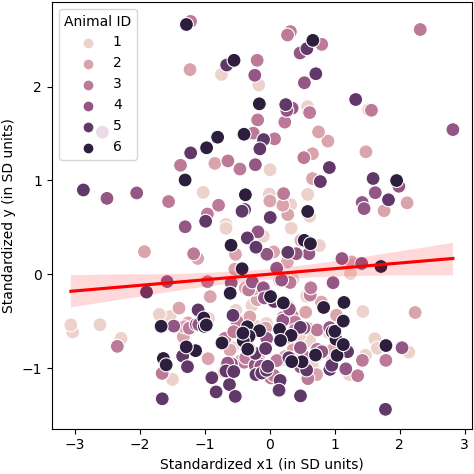

In [ ]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

transform_labels = [f'transform {i+1}' for i in range(len(results_list[0]['mae']))]

y = [np.array(res['mae']) - np.array(res['original_mae'])  for res in results_list]
x1 = [np.array(res['orthogonality']) for res in results_list]

data_dict = {
    'x1': x1,
    'y': y,
}
    
results_ml, data, prefix = st.fit_mixed_model(
    data_dict, standardize=True,
    row_labels=animal_ids, obs_labels=transform_labels,
    var_names=['orthogonality', 'MAE - original MAE'],
    title='Mixed model: orthogonality vs MAE')
print_large('orthogonality vs MAE')
print(results_ml.summary())
print(results_ml.pvalues)

fig_scatter = plots.plot_scatter(data, prefix)
plt.figure(fig_scatter.number)
plt.show()



y = [np.array(res['mae']) - np.array(res['original_mae'])  for res in results_list]
x1 = [np.array(res['angle']) for res in results_list]

data_dict = {
    'x1': x1,
    'y': y,
}
    
results_ml, data, prefix = st.fit_mixed_model(
    data_dict, standardize=True,
    row_labels=animal_ids, obs_labels=transform_labels,
    var_names=['edge angle', 'MAE - original MAE'],
    title='Mixed model: edge angles vs MAE')
print_large('edge angles vs MAE')
print(results_ml.summary())
print(results_ml.pvalues)

fig_scatter = plots.plot_scatter(data, prefix)
plt.figure(fig_scatter.number)
plt.show()



y = [np.array(res['mae']) - np.array(res['original_mae'])  for res in results_list]
x1 = [np.array(res['subspace']) for res in results_list]

data_dict = {
    'x1': x1,
    'y': y,
}
    
results_ml, data, prefix = st.fit_mixed_model(
    data_dict, standardize=True,
    row_labels=animal_ids, obs_labels=transform_labels,
    var_names=['subspace angle', 'MAE - original MAE'],
    title='Mixed model: subspace vs MAE')
print_large('subspace vs MAE')
print(results_ml.summary())
print(results_ml.pvalues)

fig_scatter = plots.plot_scatter(data, prefix)
plt.figure(fig_scatter.number)
plt.show()


y = [np.array(res['mae']) - np.array(res['original_mae'])  for res in results_list]
x1 = [np.array(res['topology']) for res in results_list]

data_dict = {
    'x1': x1,
    'y': y,
}
    
results_ml, data, prefix = st.fit_mixed_model(
    data_dict, standardize=True,
    row_labels=animal_ids, obs_labels=transform_labels,
    var_names=['persistent homology', 'MAE - original MAE'],
    title='Mixed model: homology vs MAE')
print_large('homology vs MAE')
print(results_ml.summary())
print(results_ml.pvalues)

fig_scatter = plots.plot_scatter(data, prefix)
plt.figure(fig_scatter.number)
plt.show()


y = [np.array(res['mae']) - np.array(res['original_mae'])  for res in results_list]
x1 = [np.array(res['drift']) for res in results_list]

data_dict = {
    'x1': x1,
    'y': y,
}
    
results_ml, data, prefix = st.fit_mixed_model(
    data_dict, standardize=True,
    row_labels=animal_ids, obs_labels=transform_labels,
    var_names=['drift', 'MAE - original MAE'],
    title='Mixed model: drifting vs MAE')
print_large('drifting vs MAE')
print(results_ml.summary())
print(results_ml.pvalues)

fig_scatter = plots.plot_scatter(data, prefix)
plt.figure(fig_scatter.number)
plt.show()
